In [1]:
# In terminal
# pip install pythontsa
# pip install --upgrade matplotlib
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PythonTsa.plot_acf_pacf import acf_pacf_fig
from statsmodels.tsa.arima_process import arma_generate_sample

path = "/Users/ruting/Documents/macbook/PcBack/30.ATSSB_Code/Code/ATSSB_Stochastic_Trend_Modeling"
os.chdir(path)

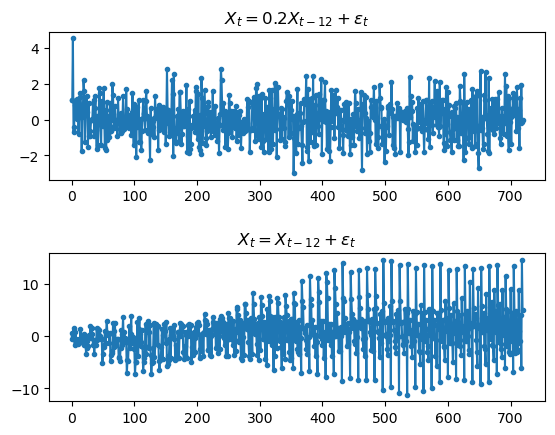

In [2]:
sar1=np.array([1,0,0,0,0,0,0,0,0,0,0,0,0,-0.2])
sar2=np.array([1,0,0,0,0,0,0,0,0,0,0,0,0,-1.0])
np.random.seed(137)
x1= arma_generate_sample(ar=sar1, ma=[1], nsample=720)
x2= arma_generate_sample(ar=sar2, ma=[1], nsample=720)
x1=pd.Series(x1)
x2=pd.Series(x2)

fig = plt.figure()
x1.plot(marker='.',ax= fig.add_subplot(211))
plt.title('$X_t=0.2X_{t-12}+\epsilon_t$')
x2.plot(marker='.',ax= fig.add_subplot(212))

fig.subplots_adjust(hspace=0.5) 

plt.title('$X_t= X_{t-12}+\epsilon_t$')

plt.savefig('TplotSARProb92.eps', dpi = 1200, 
            bbox_inches ='tight', transparent = True)
plt.savefig('TplotSARProb92.png', dpi = 1200, 
            bbox_inches ='tight', transparent = True)

plt.show()
plt.close('all')

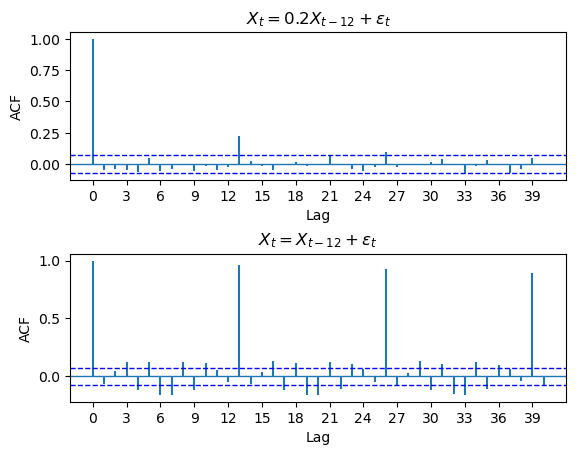

In [3]:
fig = plt.figure()
ax= fig.add_subplot(211)
acf_pacf_fig(x1,both=False,lag=40)
plt.title('$X_t=0.2X_{t-12}+\epsilon_t$')
ax= fig.add_subplot(212)
acf_pacf_fig(x2,both=False,lag=40)

fig.subplots_adjust(hspace=0.5)  # 设置上下子图之间的间距

plt.title('$X_t= X_{t-12}+\epsilon_t$')

plt.savefig('ACFPltSARProb92.png', dpi = 1200, 
            bbox_inches ='tight', transparent = True)
plt.savefig('ACFPltSARProb92.eps', dpi = 1200, 
            bbox_inches ='tight', transparent = True)

plt.show()
plt.close('all')

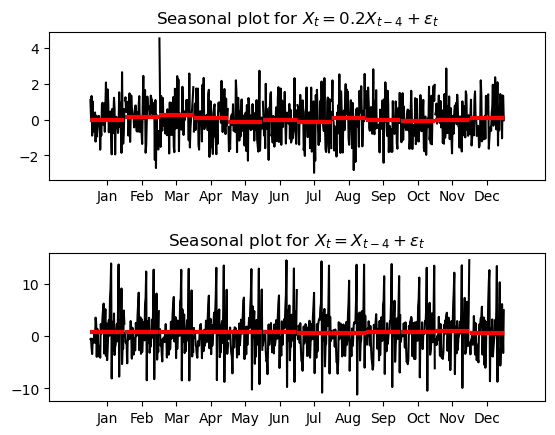

In [4]:
from statsmodels.graphics.tsaplots import month_plot
speriod=pd.date_range('2010-01', periods=len(x1),freq='M')
x1.index=speriod
x2.index=speriod
fig = plt.figure()
month_plot(x1, ax= fig.add_subplot(211))
plt.title('Seasonal plot for $X_t=0.2X_{t-4}+\epsilon_t$')
month_plot(x2, ax= fig.add_subplot(212))

fig.subplots_adjust(hspace=0.5)  

plt.title('Seasonal plot for $X_t= X_{t-4}+\epsilon_t$')
plt.savefig('SeasonalPlotsSARProb91.png', dpi = 1200, 
            bbox_inches ='tight', transparent = True)
plt.savefig('SeasonalPlotsSARProb91.eps', dpi = 1200, 
            bbox_inches ='tight', transparent = True)

plt.show()
plt.close('all')

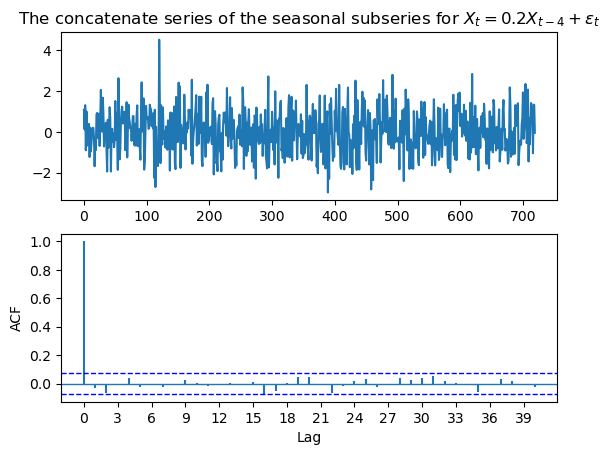

In [5]:
y=pd.DataFrame(index=range(0,int(len(x1)/12)),
    columns=['0','1','2','3','4','5','6','7','8','9','10','11'])
for i in range(0,12):
      for j in range(i, len(x1), 12):
          y.iat[int(j/12),i]=x1[j]
z=pd.concat([y['0'],y['1'],y['2'],y['3'],y['4'],y['5'],y['6'],y['7'],
    y['8'],y['9'],y['10'],y['11']],ignore_index=True)
fig = plt.figure()
ax= fig.add_subplot(211)
z.plot()
plt.title('The concatenate series of the seasonal subseries for $X_t=0.2X_{t-4}+\epsilon_t$')
             
ax= fig.add_subplot(212)
acf_pacf_fig(z,both=False,lag=40)

plt.savefig('TpltACFConcatSsubProb92.png', dpi = 1200, 
            bbox_inches ='tight', transparent = True)
plt.savefig('TpltACFConcatSsubProb92.eps', dpi = 1200, 
            bbox_inches ='tight', transparent = True)

plt.show()
plt.close('all')

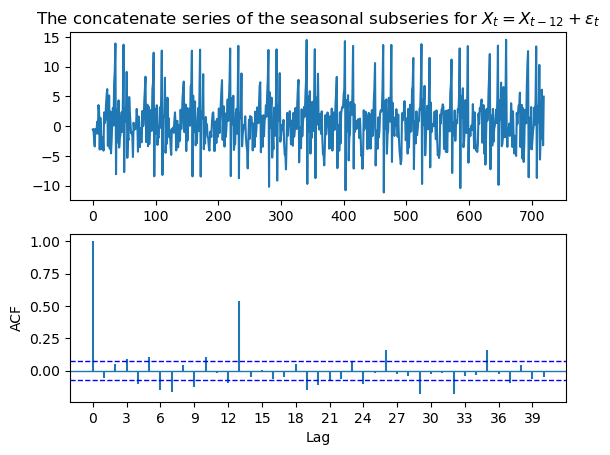

In [6]:
r=pd.DataFrame(index=range(0,int(len(x2)/12)),
    columns=['0','1','2','3','4','5','6','7','8','9','10','11'])
for i in range(0,12):
      for j in range(i, len(x2), 12):
          r.iat[int(j/12),i]=x2[j]
cr=pd.concat([r['0'],r['1'],r['2'],r['3'],r['4'],r['5'],r['6'],r['7'],
     r['8'],r['9'],r['10'],r['11']],ignore_index=True)
fig = plt.figure()
ax= fig.add_subplot(211)
cr.plot()
plt.title('The concatenate series of the seasonal subseries for $X_t=X_{t-12}+\epsilon_t$')
ax= fig.add_subplot(212)
acf_pacf_fig(cr,both=False,lag=40)

plt.savefig('TpltACFSRWSubProb92.png', dpi = 1200, 
            bbox_inches ='tight', transparent = True)
plt.savefig('TpltACFSRWSubProb92.eps', dpi = 1200, 
            bbox_inches ='tight', transparent = True)


plt.show()
plt.close('all')